# TRaining history

## Train A and B isolated
March 2nd: train_modelAB_combined_total_script.py -> model_a/b_step1 or step2?
train models, first A, then B layer per layer.

==> This seems to bring us to 93.7x% shoot acc as input to training runs 


## Combine to high plateau (step 2 - step 5)
March 10th: train_to_0999_WORKING.py: Takes step 2 as inputt, Combined AB, no hardening, stop at 99.9% reached after 256 epoch -> model_a/b_step6
train_run_20260309_170210.pkl
Note: In train_to_0999_WORKING.py, the winning path is MODE_AB, and in that path the script adds 0.30 Gaussian noise to:
* comm_logits_for_b
* meas_list_for_b
* out_list_for_b
==> This seems to bring us from 93.6% shoot acc to almost 100%

rerun this at March 14, saved intermediate as step11, epoch 226, around 98%
Stopped at 262 epoch at 99.9%: train_run_20260314_063703.pkl

## Control logit shape (step 5 - step 8)
March 11th: train_PhaseD_comm_mag_meas.py from shoot_acc=0.9637 to shoot_acc=0.9995 starting with model_a_step5.weights.h5, model_b_step5.weights.h5 ab training with loss on logit scale. Saved as step 8 

train_PhaseD_comm_mag_meas.py
train_run_20260310_170244.pkl

## Harden logits (step 8 - step 9)
Start with step 8 (models that score 99.9% with reasonable logits)
result saved as step 9
Freeze A, Harden B carefully

train_Phase_pre_gameplay_A.py
train_run_20260311_160314.pkl

March 11 drop from 100 t0 93% with drop at lambda = 0.5 (lamdna from 0 to 1 in 200 epochs)

In this run: - train_run_20260312_105545.pkl we started with lambda = 0.7 to train only A, leading to 97%. Highest with hardened lambda's so far.

# Experiment to start from step2 again and harden early
Recovers to 97% except until lambda = 1.0 (more difficult to recover for higher lamda's) For lambda = 1.0 
train_Phase_pre_gameplay_A_from_scratch.py
train_run_20260313_160011.pkl
When we set target to 99% it never reaches, stalls at 98.2%. 
Achors w_comms_b_123=[0.1, 0.1, 0.1] were stronger than for train_to_0999_WORKING.py (there it was w_comms_b_123=[0.02, 0.02, 0.02])

## Step back without hardening
==> with original achors we do reach 99%, all wit lambda = 0.0
rerun this at March 14, saved intermediate as step11, epoch 226, around 98%
Stopped at 262 epoch at 99.9%: train_run_20260314_063703.pkl
Saved intermediate model from this run as step11, epoch 226, around 98%

# Hardening from step11 checkpint at 98%, increase lambda wih 0.5 if we hit 99%
train_run_20260314_092418.pkl
Checkpiont at lamda = 0.95, performance almost 99% saved as step 12
For lambda = 1.0 drops to 93% and does not recover. For lower lambda's we reach 99.9%

# Start from step 12 (at lamda = 0.95, around 99% performance) and set a target on logits
Put a magnitide loss on comm_logits (as they are geneatre by A, no processing): 
> comm_mag_loss_raw = magnitude_target_loss(comm_logits_for_b, beta_target=1.0)
> comm_mag_loss = w_comm_mag * comm_mag_loss_raw
Let run for 200 epochs, then increase lambda with 0.1 is acc above 99%
Start with lambda 0.0 for at least 20 epochs, increase when we reach 99%
difference with earlier runs is that w_comms_a is 0 and w_comms_mag is 0.0001
==> Stalls at 97% even for lambda is 0.0 
==> train_run_20260314_124041.pkl
==> train_Phase_pre_gameplay_A_from_scratch_to_0990_with_logit_target.py

# Start from step 2 (at lamda = 0.0) and set a target on logits
Repeat this with w_comms_a=0.05, w_comm_mag=float(0.0001)
Starting from step 2
==> train_run_20260314_213940.pkl
==> Reaches lambda = 0.99 and shoot acc = 0.9864
==> Saved as check-point step 13
==> In tournament 93.3%
(btw, step12 also gives tournament at 93.x%, step2 gives 94.2%)


# RESTART: Step 2 -> Step 14 with Alpha is 0.5 iso 5.0
We first train A and B separately on teacher and show how to get to 100% win in gameplay. That is the basis. We then early stop A and B separate training and try to set up joint improvement. right now the training (logged a separate1 from Pyr_train_models - ModelB - FINAL AND WORKING.ipynb and Pyr_train_models - ModelA - FINAL AND WORKING.ipynb fails because the beta's are not aligned). Train models with beta = 10, run tournament and diagnostics.
==> We were training model B in Pyr_train_models - ModelB - FINAL AND WORKING.ipynb with beta is 1.0. With beta is 10.0 we are not achieving 100%, check alpha.
==> Set Alpha in model_b training to 0.5 (alpha * |logit| should be ~ 5)
==> Now we reach 100% score in tournament, even if in tournament alpha is still 5.0 (no hardening)m also with Alpha = 0.5 in tournament we get 100%. The Alpha only matters during training, not in forward pass.

Now try again from step2 (which is trained with wrong alpha, but |logits| should be 10) and see if e can optimize with increasing alpha.
Interrupted for lambda = 0.99 at 98% performance
train_Phase_pre_gameplay_A_from_scratch_to_0990_with_logit_target_and_corrected_alpha.py
train_run_20260316_082913.pkl
Saved as checkpoint step14, leads to 96% tournament performance

# STE on comms only
Alpha = 0.1 (because average meas_in around 20), mode=MODE_AB if (epoch%20 < 2) else MODE_B, only comms logits hardened in forward pass.
==> Reach 99.18%
==> train_Phase_pre_gameplay_STE.py
==> train_run_20260316_153645.pkl
==> Saved as step 15
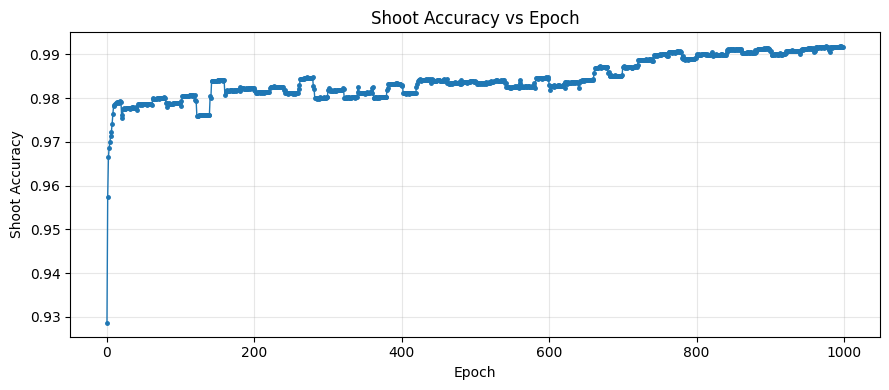

# STE on COMMS and MEAS
Alpha = 0.1, mode=MODE_AB if (epoch%20 < 2) else MODE_B, 
train_run_20260317_154712.pkl
train_Phase_pre_gameplay_STE - Meas and Comm.py
Best (almost 99.9%) after ~ epoch 220 stored as step16, last (98.6%) after 1000 stored as step 17
Tournament with step17 (also using alpha = 0.1) 99.7%
If we switch to Alpha = 1.0 we get for tournament: 87.1%
[epoch 999] Training mode: B
epoch 999  total=0.1839  shoot_acc=0.9866  comm_a_loss=0.0022  meas_in_a_loss=0.0052  comms_b_loss=0.0752  shoot_loss=0.0585  comm_mag_loss=0.0176  comm_mag_loss_raw=175.6742  mean_abs_comm_for_b=14.8596  meas_mag_loss=0.0252  meas_mag_loss_raw=252.0307  mean_abs_meas_in_a=13.7340  comm_mag_beta_target=10.0000  w_comm_mag=0.0001  w_meas_mag=0.0001  lambda_harden=0.0000  lr_a*1000=0.0100  lr_b*1000=0.1000  meas_in_a_per_0=0.0009  meas_in_a_per_1=0.0028  meas_in_a_per_2=0.0040  meas_in_a_per_3=0.0131  comms_b_per_0=0.0786  comms_b_per_1=0.0758  comms_b_per_2=0.0712 

# Logit magnitude regularization on internal b meas_b
Alpha = 0.3. Add magnitide regularization also to the internal logits in model B (meas_b) that feed in to the SR layer
Start from step 2
Result saved as step20
100% score at gameplay!

[epoch 28] Training mode: B
epoch 028  total=0.0036  shoot_acc=1.0000  comm_a_loss=0.0000  meas_in_a_loss=0.0001  comms_b_loss=0.0000  shoot_loss=0.0000  comm_mag_loss=0.0020  comm_mag_loss_raw=19.6557  mean_abs_comm_for_b=14.1827  meas_mag_loss=0.0015  meas_mag_loss_raw=14.6166  mean_abs_meas_in_a=12.2441  meas_b_mag_loss=0.0000  meas_b_mag_loss_raw=0.1679  mean_abs_meas_b=10.0049  mean_abs_gun_logits=10.4445  comm_mag_beta_target=10.0000  w_comm_mag=0.0001  w_meas_mag=0.0001  w_meas_b_mag=0.0001  lambda_harden=0.0000  lr_a*1000=0.0100  lr_b*1000=0.1000  meas_in_a_per_0=0.0000  meas_in_a_per_1=0.0001  meas_in_a_per_2=0.0001  meas_in_a_per_3=0.0000  comms_b_per_0=0.0001  comms_b_per_1=0.0000  comms_b_per_2=0.0000


[epoch 29] Training mode: B
[train] interrupted by user.
[log] flushed -> C:\Users\nly99857\OneDrive - Philips\SW Projects\QSeaBattle\WIP\logs\train_run_20260319_080619.pkl
[weights] saved: model_a_epoch_0029_interrupted.weights.h5, model_b_epoch_0029_interrupted.weights.h5
[weights] saved: model_a_latest.weights.h5, model_b_latest.weights.h5
{'log_path': 'C:\\Users\\nly99857\\OneDrive - Philips\\SW Projects\\QSeaBattle\\WIP\\logs\\train_run_20260319_080619.pkl', 'epochs_recorded': 29, 'interrupted': True}

Running tournament...
Tournament finished.
Pyramid bootstrap tournament over 1000: 1.0000 ± 0.0000
Weights used: model_a from C:\Users\nly99857\OneDrive - Philips\SW Projects\QSeaBattle\WIP\checkpoints\combined_ab\model_a_step20.weights.h5, model_b from C:\Users\nly99857\OneDrive - Philips\SW Projects\QSeaBattle\WIP\checkpoints\combined_ab\model_b_step20.weights.h5
Alpha for SR layer: 0.3
Harden between levels: model_a=False, model_b=False

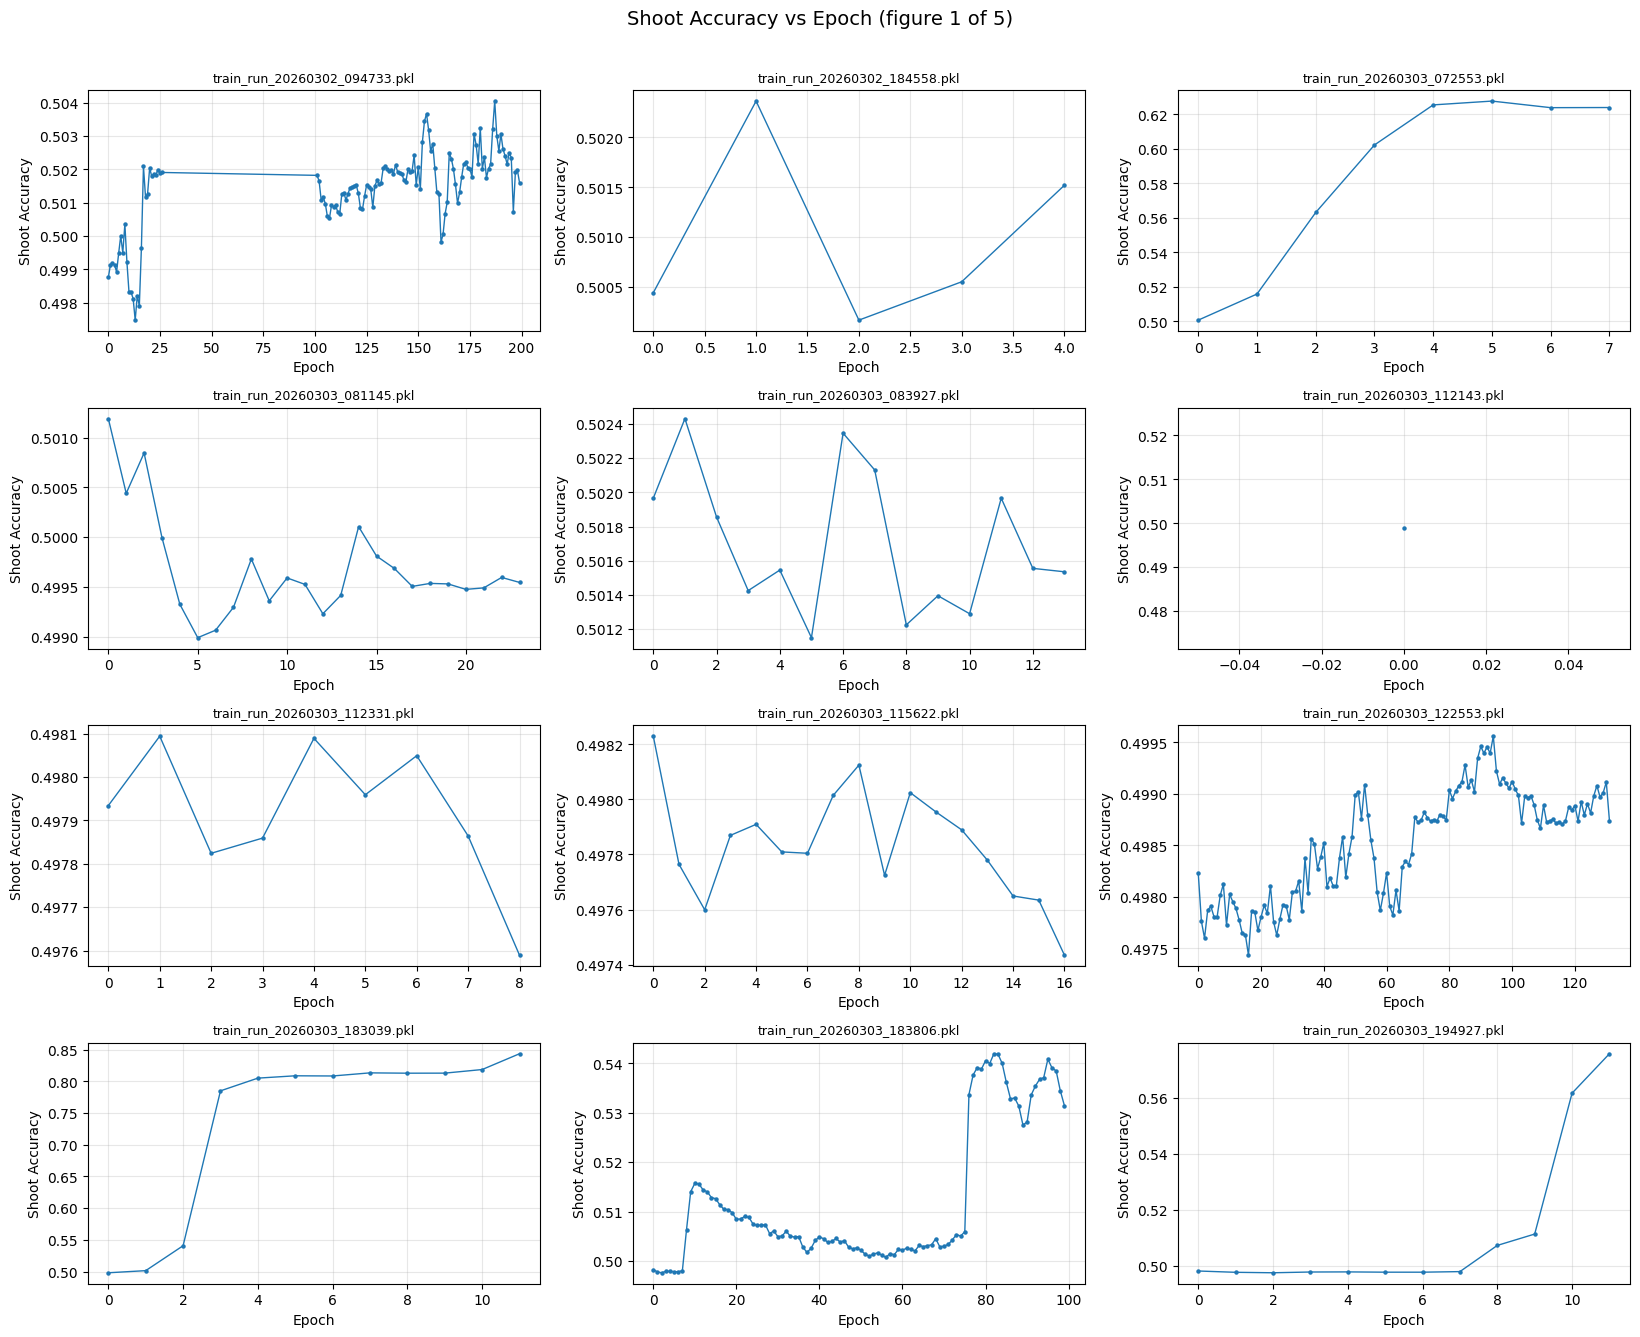

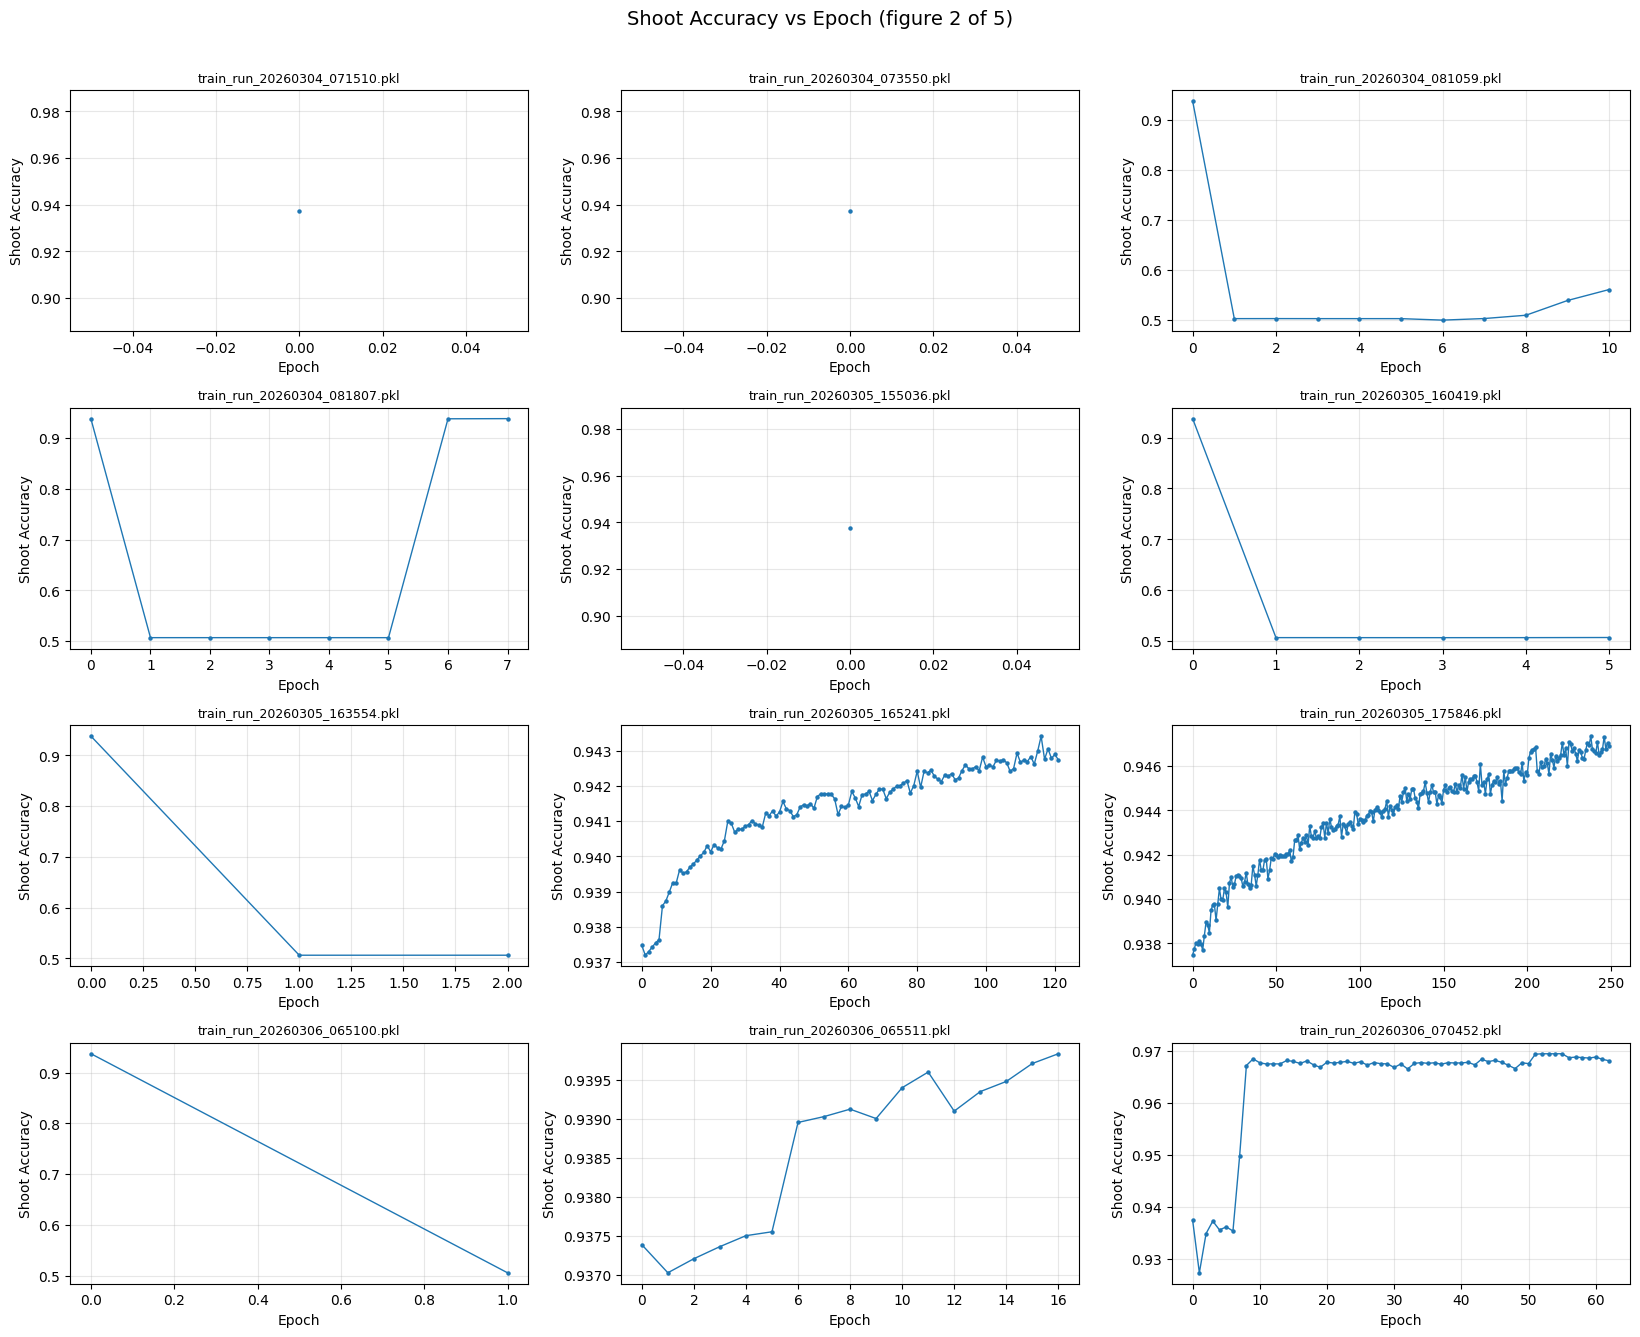

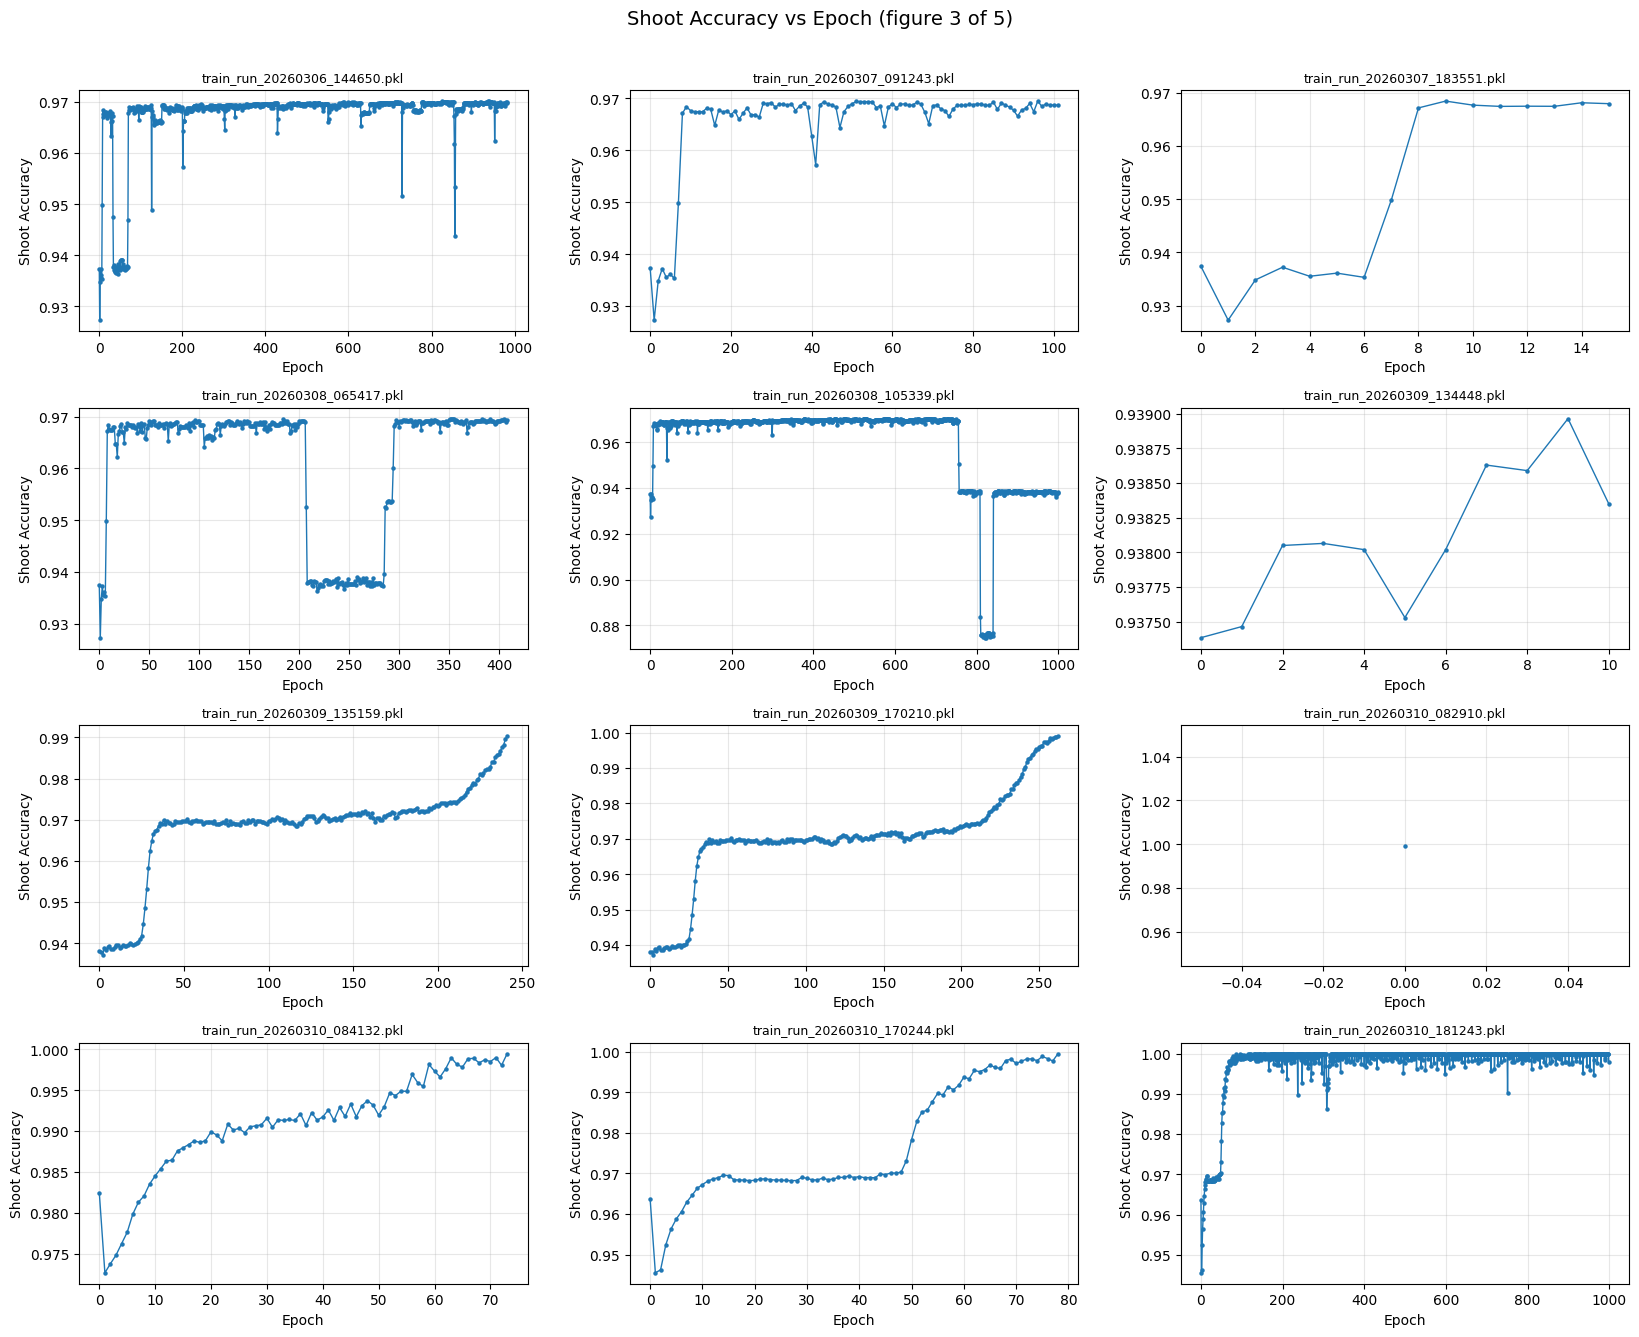

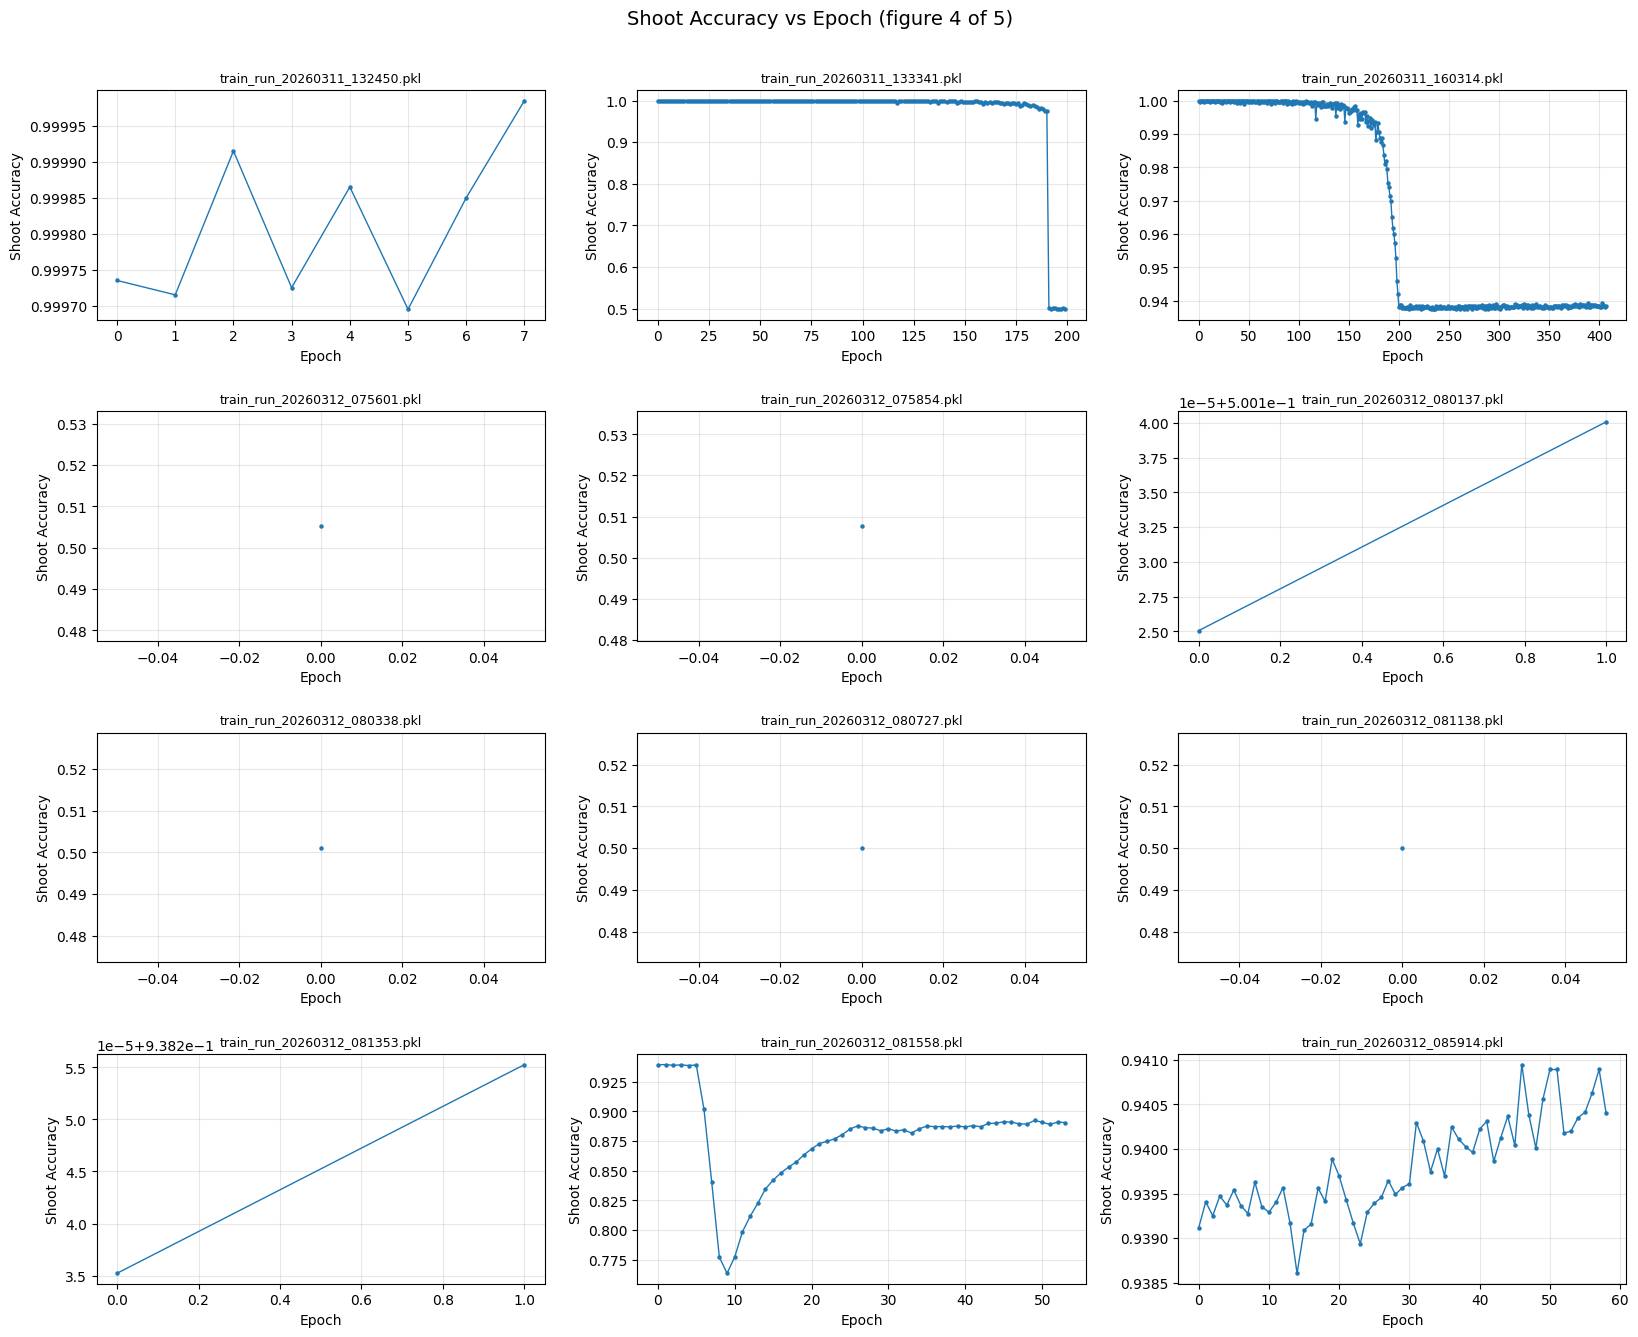

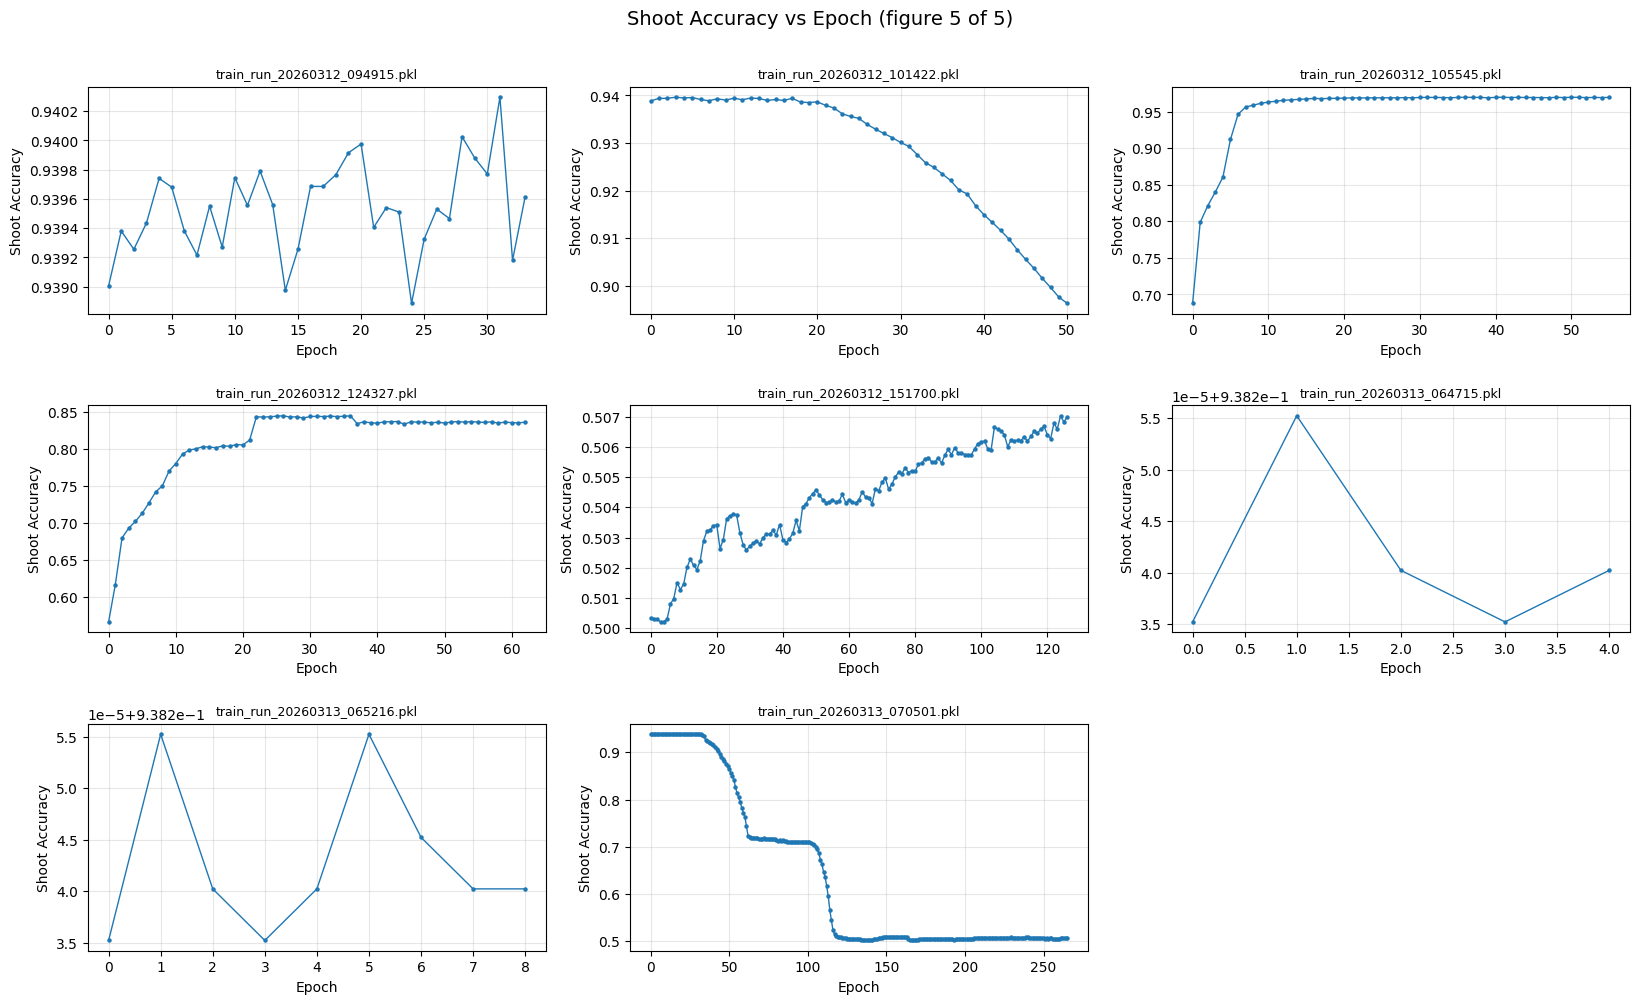